Introduction

Loan approval is a critical process in the banking and financial sector. Manual evaluation of loan applications is time-consuming and prone to human bias. This project aims to build a machine learning–based loan prediction system that can automatically predict whether a loan application will be approved or rejected based on applicant details.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [60]:
df=pd.read_csv('loan.csv')

In [61]:
df.head()

,Name,Age,Occupation,Annual Income (INR),Credit Score (300-850),Lender,Loan Purpose,Approved Loan Amount (INR),Months of Payment,Interest Rate (%),Monthly EMI (INR),DTI Ratio,Loan Status (Pass/Rejected)
0,Person 0001,28,Retail Manager,464368,831,State Bank of India,Medical Emergency,798376,24,5.90,35349,0.913,Rejected
1,Person 0002,64,CEO,42483570,850,Bajaj Finserv,Travel/Vacation,1052728,24,6.48,46886,0.013,Pass
2,Person 0003,74,Retired (Pension),181737,850,Kotak Mahindra Bank,Wedding Expenses,1461692,48,3.87,32919,2.174,Rejected
3,Person 0004,32,Freelance Designer,958718,811,Bajaj Finserv,Home Renovation,551682,36,3.20,16092,0.201,Pass
4,Person 0005,32,Software Engineer,1682127,850,Bajaj Finserv,Debt Consolidation,737919,60,6.49,14435,0.103,Pass


In [62]:
df.tail()

,Name,Age,Occupation,Annual Income (INR),Credit Score (300-850),Lender,Loan Purpose,Approved Loan Amount (INR),Months of Payment,Interest Rate (%),Monthly EMI (INR),DTI Ratio,Loan Status (Pass/Rejected)
9995,Person 9996,18,University Student,14734,647,Bajaj Finserv,Vehicle Purchase,625564,48,23.05,20067,16.344,Rejected
9996,Person 9997,22,University Student,74788,595,State Bank of India,Consumer Durable/Tech,657370,24,24.28,34848,5.591,Rejected
9997,Person 9998,24,University Student,82219,531,State Bank of India,Consumer Durable/Tech,0,12,34.78,0,0.000,Rejected
9998,Person 9999,47,Retail Manager,1520951,596,HDFC Bank,Medical Emergency,558890,12,19.02,51511,0.406,Rejected
9999,Person 10000,37,Doctor,873282,518,State Bank of India,Debt Consolidation,0,48,33.82,0,0.000,Rejected


In [63]:
df.shape

(10000, 13)

In [64]:
df.ndim

2

In [65]:
df.rename(columns={'Loan Status (Pass/Rejected)': 'Loan Status'}, inplace=True)

In [66]:
df.drop('Name', axis=1,inplace=True)


In [67]:
df.isna().sum()

Age                           0
Occupation                    0
Annual Income (INR)           0
Credit Score (300-850)        0
Lender                        0
Loan Purpose                  0
Approved Loan Amount (INR)    0
Months of Payment             0
Interest Rate (%)             0
Monthly EMI (INR)             0
DTI Ratio                     0
Loan Status                   0
dtype: int64

In [68]:
df.isna().sum()/len(df)*100

Age                           0.0
Occupation                    0.0
Annual Income (INR)           0.0
Credit Score (300-850)        0.0
Lender                        0.0
Loan Purpose                  0.0
Approved Loan Amount (INR)    0.0
Months of Payment             0.0
Interest Rate (%)             0.0
Monthly EMI (INR)             0.0
DTI Ratio                     0.0
Loan Status                   0.0
dtype: float64

In [69]:
df.dtypes

Age                             int64
Occupation                     object
Annual Income (INR)             int64
Credit Score (300-850)          int64
Lender                         object
Loan Purpose                   object
Approved Loan Amount (INR)      int64
Months of Payment               int64
Interest Rate (%)             float64
Monthly EMI (INR)               int64
DTI Ratio                     float64
Loan Status                    object
dtype: object

In [70]:
df.columns

Index(['Age', 'Occupation', 'Annual Income (INR)', 'Credit Score (300-850)',
       'Lender', 'Loan Purpose', 'Approved Loan Amount (INR)',
       'Months of Payment', 'Interest Rate (%)', 'Monthly EMI (INR)',
       'DTI Ratio', 'Loan Status'],
      dtype='object')

In [71]:
for i in df.columns:
    print(df[i].unique())
    print('*'*100)

[28 64 74 32 31 43 24 70 52 20 51 26 36 27 23 25 33 47 46 38 34 21 40 44
 22 63 42 19 30 41 39 29 56 75 37 72 18 83 35 48 54 57 69 45 53 71 80 65
 49 60 76 78 58 81 50 66 59 62 73 68 82 79 61 55 67 84 77]
****************************************************************************************************
['Retail Manager' 'CEO' 'Retired (Pension)' 'Freelance Designer'
 'Software Engineer' 'University Student' 'Construction Worker' 'Doctor'
 'High School Teacher']
****************************************************************************************************
[  464368 42483570   181737 ...    82219  1520951   873282]
****************************************************************************************************
[831 850 811 829 806 782 801 764 834 839 833 842 824 812 846 832 821 838
 816 813 814 808 841 848 815 820 817 819 835 849 790 822 837 845 799 840
 847 804 818 773 825 793 823 830 797 805 843 781 809 827 786 783 795 826
 844 788 792 836 800 802 810 828 807 794 785 796 80

In [72]:
df.duplicated().sum()

np.int64(0)

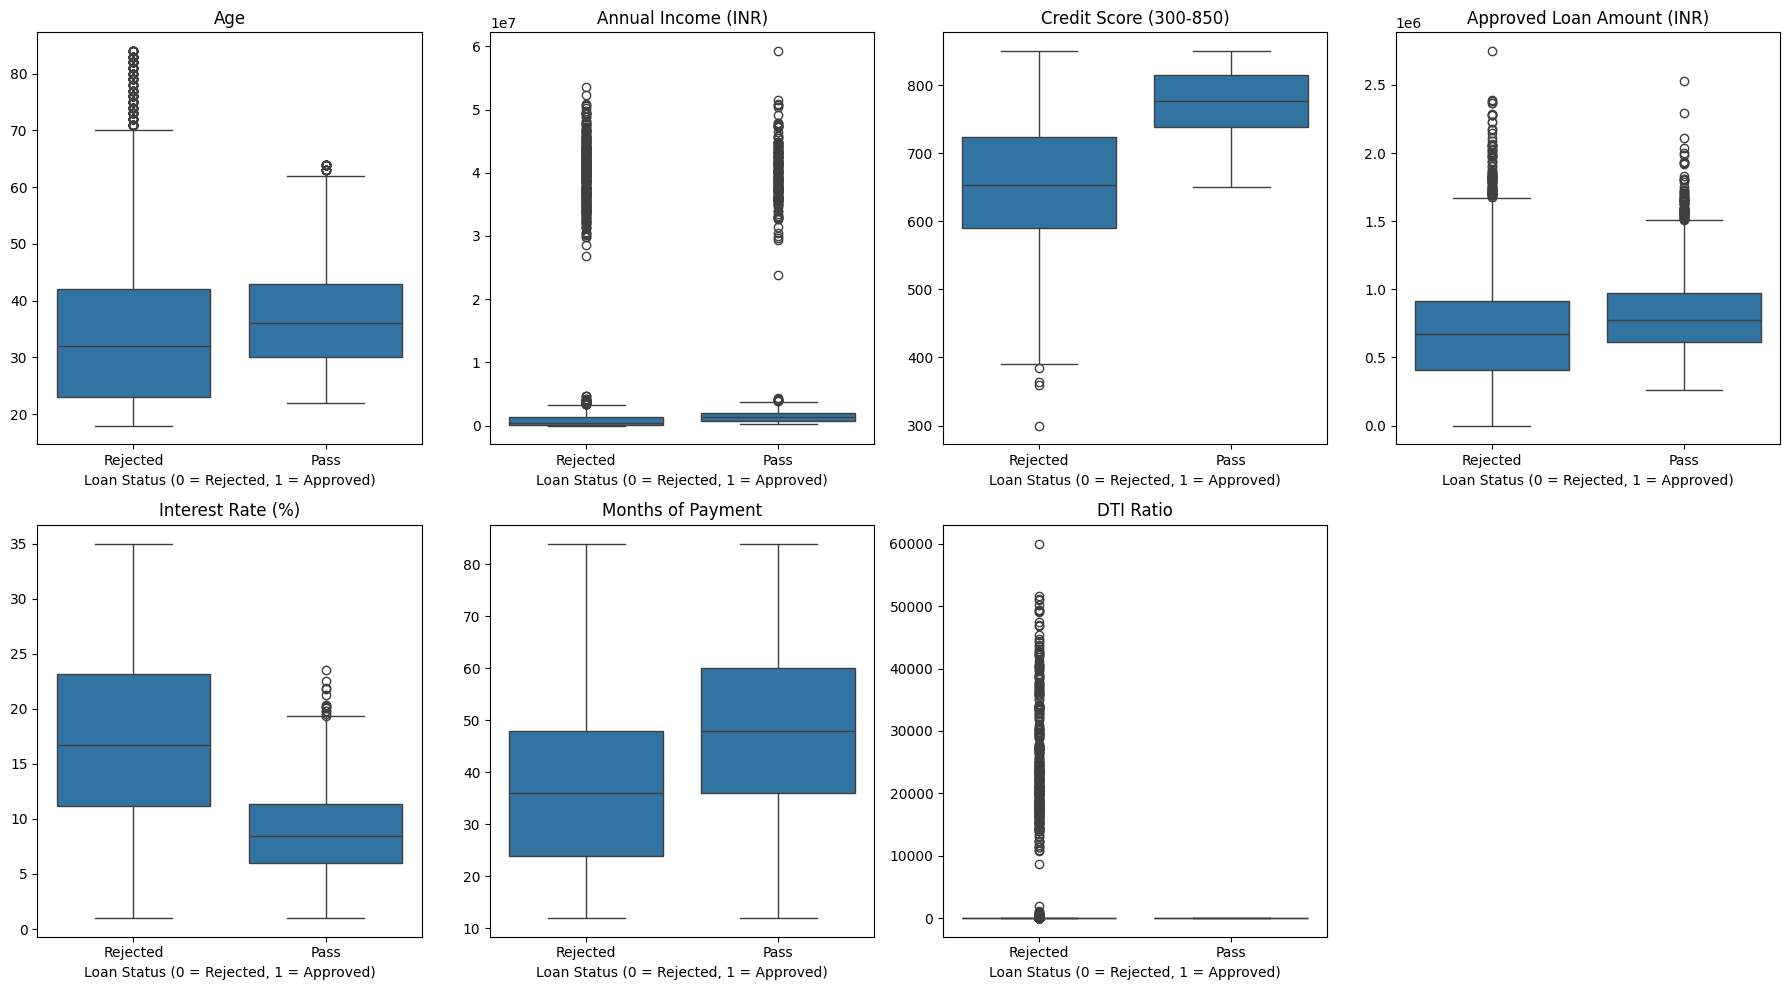

In [73]:

features = [
    "Age",
    "Annual Income (INR)",
    "Credit Score (300-850)",
    "Approved Loan Amount (INR)",
    "Interest Rate (%)",
    "Months of Payment",
    "DTI Ratio"
]

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x="Loan Status", y=feature, data=df)
    plt.title(feature)
    plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
    plt.ylabel("")

plt.tight_layout()
plt.show()


In [74]:
lb = LabelEncoder()
df["Loan Status"] = lb.fit_transform(df["Loan Status"])

ohe_1 = OneHotEncoder(sparse_output=False)
ohe_2 = OneHotEncoder(sparse_output=False)
ohe_3 = OneHotEncoder(sparse_output=False)

occ = pd.DataFrame(ohe_1.fit_transform(df[["Occupation"]]),
                   columns=ohe_1.get_feature_names_out())

lend = pd.DataFrame(ohe_2.fit_transform(df[["Lender"]]),
                    columns=ohe_2.get_feature_names_out())

purpose = pd.DataFrame(ohe_3.fit_transform(df[["Loan Purpose"]]),
                   columns=ohe_3.get_feature_names_out())


In [75]:
df = pd.concat([df, occ, lend, purpose], axis=1)

In [76]:
df.drop(["Occupation", "Lender", "Loan Purpose"], axis=1, inplace=True)

In [77]:
x = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

In [78]:
y.value_counts()

Loan Status
1    6768
0    3232
Name: count, dtype: int64

In [79]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

print(x_train.shape,x_test.shape)

(8000, 31) (2000, 31)


In [80]:
sm=SMOTE(random_state=42)
x_train_bal,y_train_bal=sm.fit_resample(x_train,y_train)

y_train_bal.value_counts()

Loan Status
1    5414
0    5414
Name: count, dtype: int64

In [81]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_bal)
x_test_scaled=scaler.transform(x_test)

In [82]:

models={
    'KNN':KNeighborsClassifier(),
    'DecisionTree':DecisionTreeClassifier(random_state=42),
    'RandomForest':RandomForestClassifier(random_state=42),
    'SVM':SVC(probability=True, random_state=42),
    'AdaBoost':AdaBoostClassifier(random_state=42),
    'NaiveBayes':GaussianNB()
}
results = []


In [ ]:
print(f"{'Model':<25} | {'Train Acc':<10} | {'Test Acc':<10} | {'Status'}")
print("-" * 65)

results = []

for name, model in models.items():
    
    model.fit(x_train_scaled, y_train_bal)
    
    y_train_pred = model.predict(x_train_scaled)
    y_test_pred  = model.predict(x_test_scaled)
    
    tr_acc = accuracy_score(y_train_bal, y_train_pred)
    ts_acc = accuracy_score(y_test, y_test_pred)
    gap = tr_acc - ts_acc

    
    if gap > 0.05:
        status = 'Overfitting'
    elif tr_acc < 0.60 and ts_acc < 0.60:
        status = 'Underfitting'
    else:
        status = 'Good Model'

    results.append({
        "Model": name,
        "Train Acc": tr_acc,
        "Test Acc": ts_acc,
        "Gap": gap,
        "Status": status
    })

    print(f"{name:<25} | {tr_acc:.4f}   | {ts_acc:.4f}   | {status}")

    print("\nTest Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    
    print("\nTest Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print("-" * 65)


Model                     | Train Acc  | Test Acc   | Status
-----------------------------------------------------------------
KNN                       | 0.9535   | 0.9095   | Good Model

Test Confusion Matrix:
[[ 596   50]
 [ 131 1223]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       646
           1       0.96      0.90      0.93      1354

    accuracy                           0.91      2000
   macro avg       0.89      0.91      0.90      2000
weighted avg       0.92      0.91      0.91      2000

-----------------------------------------------------------------
DecisionTree              | 1.0000   | 0.9990   | Good Model

Test Confusion Matrix:
[[ 646    0]
 [   2 1352]]

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       646
           1       1.00      1.00      1.00      1354

    accuracy                      

Best model

In [84]:

best_model_name = "AdaBoost"
best_model = models[best_model_name]


y_test_pred = best_model.predict(x_test_scaled)
final_acc = accuracy_score(y_test, y_test_pred)

print(f"Final Model Choice: {best_model_name}")
print(f"Final Test Accuracy: {final_acc * 100:.2f}%")


Final Model Choice: AdaBoost
Final Test Accuracy: 97.05%


Hyperparameter Tunning

In [85]:
param_spaces = {
    "KNN": {"n_neighbors": [3, 5, 7, 11]},
    "DecisionTree": {"max_depth": [3, 5, 7, None]},
    "RandomForest": {"n_estimators": [100, 200], "max_depth": [5, 10, None]},
    "SVM": {"C": [0.1, 1, 10]},
    "AdaBoost": {"n_estimators": [50, 100]}
}


best_model_name = "AdaBoost" 
best_model = models[best_model_name]

if best_model_name in param_spaces:
    search = RandomizedSearchCV(
        best_model,
        param_spaces[best_model_name],
        n_iter=10,
        cv=3,
        scoring="accuracy",
        random_state=42
    )
    search.fit(x_train_scaled, y_train_bal)
    tuned = search.best_estimator_
    print(f"Tuned {best_model_name} Best Parameters: {search.best_params_}")
else:
    tuned = best_model
    print(f"No tuning space defined for {best_model_name}, using default.")


tuned_acc = tuned.score(x_test_scaled, y_test)
print(f"Final Tuned Test Accuracy: {tuned_acc * 100:.2f}%")

c:\Users\VICTUS\Desktop\Data Science\new project\proj_env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Tuned AdaBoost Best Parameters: {'n_estimators': 100}
Final Tuned Test Accuracy: 97.20%


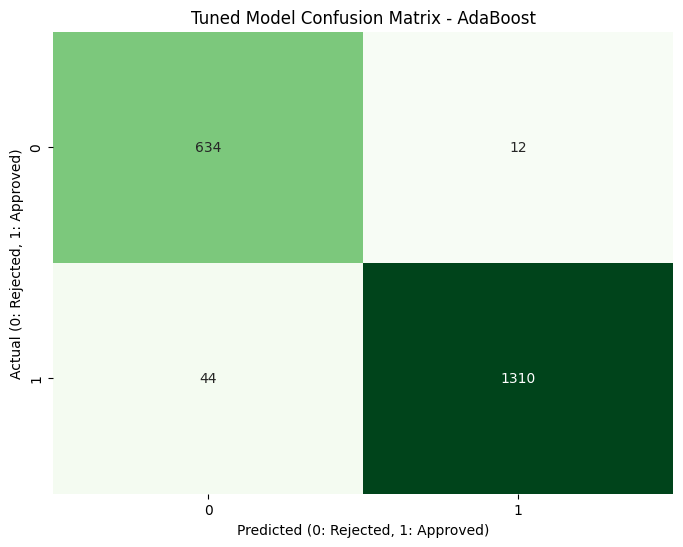


Final Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       646
           1       0.99      0.97      0.98      1354

    accuracy                           0.97      2000
   macro avg       0.96      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [86]:
pred_test = tuned.predict(x_test_scaled)

cm = confusion_matrix(y_test, pred_test)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title(f"Tuned Model Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted (0: Rejected, 1: Approved)")
plt.ylabel("Actual (0: Rejected, 1: Approved)")
plt.show()


print("\nFinal Classification Report (Test Data):")
print(classification_report(y_test, pred_test))

In [87]:
import pickle

with open("final_model.pkl", "wb") as f:
    pickle.dump(tuned, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

feature_columns = x.columns.tolist()
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

try:
    with open("label_encoder.pkl", "wb") as f:
        pickle.dump(lb, f)
except NameError:
    print("Warning: 'lb' not found. Ensure you handle categorical encoding in deployment.")

print("--- All deployment files saved successfully! ---")
print(" Model saved sucessfully")

--- All deployment files saved successfully! ---
 Model saved sucessfully


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")


In [ ]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]


In [ ]:
# Pre-processing: Remove Outliers
df_clean = df.copy()
if 'Annual Income (INR)' in df_clean.columns:
    df_clean = remove_outliers(df_clean, 'Annual Income (INR)')
if 'Approved Loan Amount (INR)' in df_clean.columns:
    df_clean = remove_outliers(df_clean, 'Approved Loan Amount (INR)')

# 1. Loan Status Distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='Loan Status', palette='viridis')
plt.title('Distribution of Loan Status (Outliers Removed)', fontsize=16)
plt.show()

# 2. Loan Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='Approved Loan Amount (INR)', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Approved Loan Amounts (Outliers Removed)', fontsize=16)
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_clean[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()
